# Dominiks Soft Drink Analysis

From 1989 to 1994, Chicago Booth and Dominick's Finer Foods entered into a partnership for store-level research into shelf management and pricing. Randomized experiments were conducted in more than 25 different categories throughout all stores in this 100-store chain. As a byproduct of this research cooperation, approximately nine years of store-level data on the sales of more than 3,500 UPCs is available in this database. This data is unique for the breadth of its coverage and for the information available on retail margins.

* `MOVE` -> Number of units sold that day/week (Target).

* 'SALE':
* B = Bonus Purchase (Prime Purchase)
* C = Coupon
* S = Sale (Simple Sale)
* (Empty) = No promotion.

* `PRICE` -> Exact amount paid by the customer at the register (including the promotion!!).

* `PROFIT` -> Profit Percentage! How much the store keeps.

**Useful for Cannibalization**
* `UPC` -> Product Code
* `STORE` -> Location
* `WEEK` -> Time

In [175]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load data from a CSV file"""
    return pd.read_csv(file_path, encoding = 'latin1')

data = load_data('softDrinks.csv')
print(data.shape)
data.head()

(17476933, 14)


,UPC,STORE,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,COM_CODE,DESCRIP,SIZE,CASE,NITEM
0,179.0,2,1,1,1,10.0,NaN,99.9,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
1,179.0,2,2,0,1,0.0,NaN,0.0,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
2,179.0,2,3,0,1,0.0,NaN,0.0,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
3,179.0,2,4,2,1,10.0,NaN,99.9,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
4,179.0,2,5,0,1,0.0,NaN,0.0,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290


## Cleaning Data

In [176]:
# Keep only rows where OK is 1
try:
    data = data[data.OK == 1]            
    data = data.drop(columns = ['OK', 'NITEM', 'CASE'], axis = 1)
    print('Columns deleted.')
except:
    print("Columns still deleted or doesn't exist.")

data.head()

Columns deleted.


,UPC,STORE,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,COM_CODE,DESCRIP,SIZE
0,179.0,2,1,1,1,10.0,NaN,99.9,225,BLOOD GLUCOSE SCREEN,EACH
1,179.0,2,2,0,1,0.0,NaN,0.0,225,BLOOD GLUCOSE SCREEN,EACH
2,179.0,2,3,0,1,0.0,NaN,0.0,225,BLOOD GLUCOSE SCREEN,EACH
3,179.0,2,4,2,1,10.0,NaN,99.9,225,BLOOD GLUCOSE SCREEN,EACH
4,179.0,2,5,0,1,0.0,NaN,0.0,225,BLOOD GLUCOSE SCREEN,EACH


In [177]:
# If price is not promotion & equal to 0 -> error;
_ = data[(data.SALE.isna()) & (data.PRICE == 0.0)].index
print(f"Total: {len(_)}.")

try:
    data = data.drop(index = _, axis = 0)
    data = data.reset_index(drop = True)
    print("Index dropped successfully.")
except:
    print('Index not dropped.')

Total: 6704029.
Index dropped successfully.


In [178]:
# Data without promotion
data_no_prom = data[data.SALE.isna()]
print(f'Data no promotion shape: {data_no_prom.shape}')

# Data with simple promotion
data_prom = data[data.SALE == 'S']
print(f'Data simple promotion shape: {data_prom.shape}')
data_prom.head()

Data no promotion shape: (7349253, 11)
Data simple promotion shape: (1660917, 11)


,UPC,STORE,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,COM_CODE,DESCRIP,SIZE
641,418.0,71,306,3,1,6.99,S,10.58,235,~DIET CRYSTAL PEPSI,24/12O
643,418.0,71,300,4,1,5.99,S,-4.34,235,~DIET CRYSTAL PEPSI,24/12O
646,418.0,107,348,1,1,5.99,S,-21.03,235,~DIET CRYSTAL PEPSI,24/12O
647,418.0,86,326,1,1,4.99,S,-11.22,235,~DIET CRYSTAL PEPSI,24/12O
648,418.0,71,301,1,1,5.99,S,-4.34,235,~DIET CRYSTAL PEPSI,24/12O


In [179]:
# Keep Relevant Columns
data_no_prom = data_no_prom[['UPC', 'STORE', 'WEEK', 'PRICE', 'MOVE']]
data_prom = data_prom[['UPC', 'STORE', 'WEEK', 'PRICE', 'MOVE']]

# Check on specific product (the higther) & Specific Store
data_no_prom = data_no_prom[(data_no_prom.UPC == data_prom.UPC.value_counts().index[0]) & (data_no_prom.STORE == 2)]
data_prom = data_prom[(data_prom.UPC == data_prom.UPC.value_counts().index[0]) & (data_prom.STORE == 2)]

# Add column promotion or Not
data_no_prom['Promotion'] = 0
data_prom['Promotion'] = 1

# Concat & Order weeks
data_concat = pd.concat((data_no_prom, data_prom)).sort_values(by = 'WEEK', ascending = True).reset_index(drop = True)
print(data_concat.shape)
data_concat.head(10)

(311, 6)


,UPC,STORE,WEEK,PRICE,MOVE,Promotion
0,1.200000e+09,2,1,1.79,50,0
1,1.200000e+09,2,2,1.79,32,0
2,1.200000e+09,2,3,1.79,48,0
3,1.200000e+09,2,5,1.79,39,0
4,1.200000e+09,2,7,1.79,52,0
5,1.200000e+09,2,8,1.79,65,0
6,1.200000e+09,2,9,1.79,607,0
7,1.200000e+09,2,10,1.79,87,0
8,1.200000e+09,2,11,0.89,399,1
9,1.200000e+09,2,12,1.79,50,0


In [180]:
# Shift all by 1
data_concat['Price_Prev'] = data_concat.groupby(['UPC', 'STORE'])['PRICE'].shift(1)

# Discount -> # np.ceil((((t -1) - t) / (t - 1)) * 100)
data_concat['Discount'] = np.where(data_concat['Promotion'] == 1, ((data_concat['Price_Prev'] - data_concat['PRICE']) / data_concat['Price_Prev']) * 100, 0)
data_concat['Discount'] = np.where(data_concat['Discount'] < 0, 0, data_concat['Discount'])

print(data_concat.shape)
data_concat.head(10)

(311, 8)


,UPC,STORE,WEEK,PRICE,MOVE,Promotion,Price_Prev,Discount
0,1.200000e+09,2,1,1.79,50,0,NaN,0.00000
1,1.200000e+09,2,2,1.79,32,0,1.79,0.00000
2,1.200000e+09,2,3,1.79,48,0,1.79,0.00000
3,1.200000e+09,2,5,1.79,39,0,1.79,0.00000
4,1.200000e+09,2,7,1.79,52,0,1.79,0.00000
5,1.200000e+09,2,8,1.79,65,0,1.79,0.00000
6,1.200000e+09,2,9,1.79,607,0,1.79,0.00000
7,1.200000e+09,2,10,1.79,87,0,1.79,0.00000
8,1.200000e+09,2,11,0.89,399,1,1.79,50.27933
9,1.200000e+09,2,12,1.79,50,0,0.89,0.00000


In [181]:
data_prom2 = data_concat[data_concat.Promotion == 1].reset_index(drop = True)
data_no_prom2 = data_concat[data_concat.Promotion == 0].reset_index(drop = True)

data_prom2.head()

,UPC,STORE,WEEK,PRICE,MOVE,Promotion,Price_Prev,Discount
0,1.200000e+09,2,11,0.89,399,1,1.79,50.279330
1,1.200000e+09,2,43,1.29,66,1,1.79,27.932961
2,1.200000e+09,2,91,0.99,557,1,1.89,47.619048
3,1.200000e+09,2,105,1.29,139,1,1.49,13.422819
4,1.200000e+09,2,107,0.99,505,1,1.49,33.557047


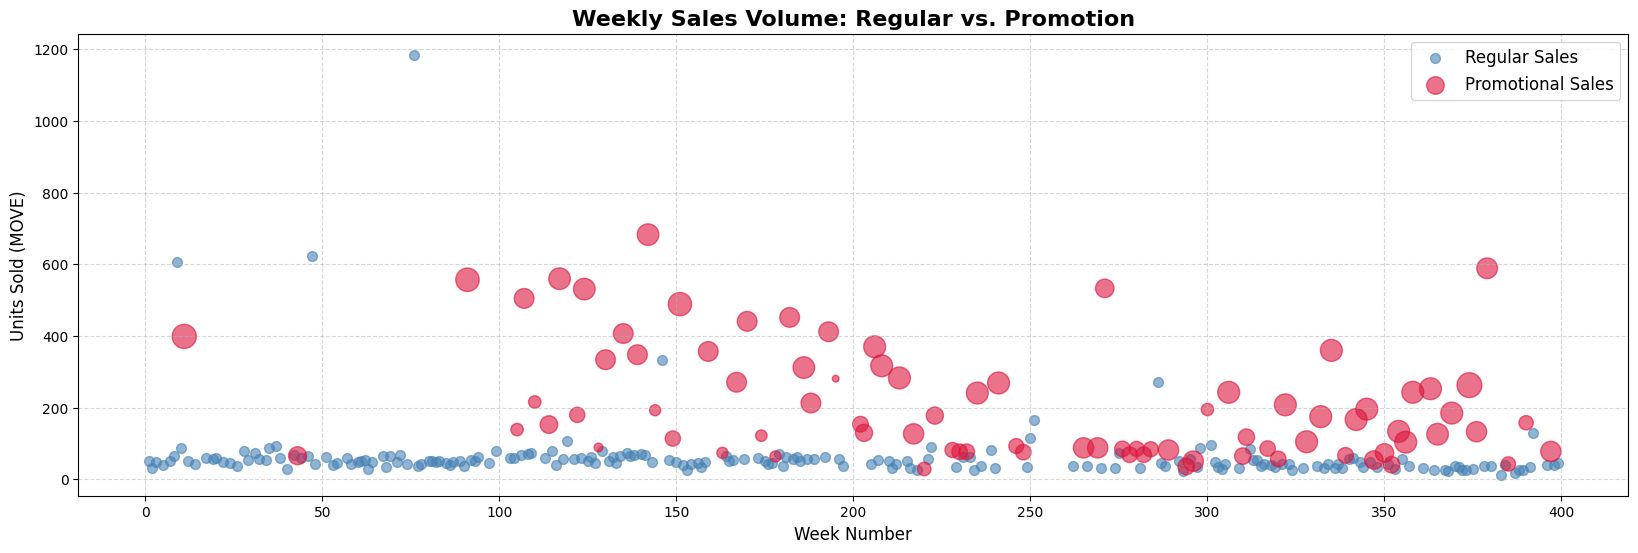

In [182]:
plt.figure(figsize = (20, 6))
plt.scatter(data_no_prom2.WEEK, data_no_prom2.MOVE, label = 'Regular Sales', color = 'steelblue', alpha = 0.6, s = 50)
plt.scatter(data_prom2.WEEK, data_prom2.MOVE, label = 'Promotional Sales', color = 'crimson', alpha = 0.6, s = data_prom2.Discount * 6)
plt.title('Weekly Sales Volume: Regular vs. Promotion', fontsize=16, fontweight='bold')
plt.xlabel('Week Number', fontsize = 12)
plt.ylabel('Units Sold (MOVE)', fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

## Create Baseline

In [183]:
data_modelling = data_no_prom2[['WEEK', 'PRICE', 'MOVE']]
print(data_modelling.shape)
data_modelling.head()

(205, 3)


,WEEK,PRICE,MOVE
0,1,1.79,50
1,2,1.79,32
2,3,1.79,48
3,5,1.79,39
4,7,1.79,52


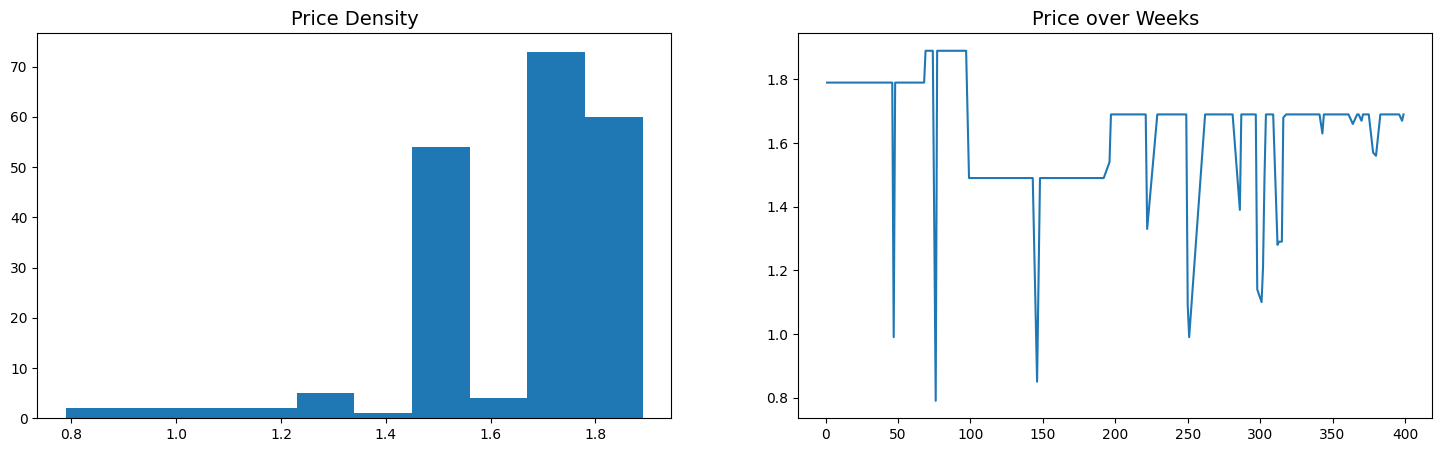

[1.79 0.99 1.89 0.79 1.49 0.85 1.54 1.69 1.33 1.09 1.39 1.14 1.1  1.21
 1.28 1.29 1.68 1.63 1.66 1.67 1.57 1.56]
Median Price: 1.69
Mean Price: 1.6369756097560972


In [184]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (18, 5))
ax1.hist(data_modelling.PRICE)
ax1.set_title('Price Density', fontsize = 14)

ax2.plot(data_modelling.WEEK, data_modelling.PRICE)
ax2.set_title('Price over Weeks', fontsize = 14)
plt.show()

print(data_modelling.PRICE.unique())
print(f'Median Price: {np.median(data_modelling.PRICE)}')
print(f'Mean Price: {np.mean(data_modelling.PRICE)}')

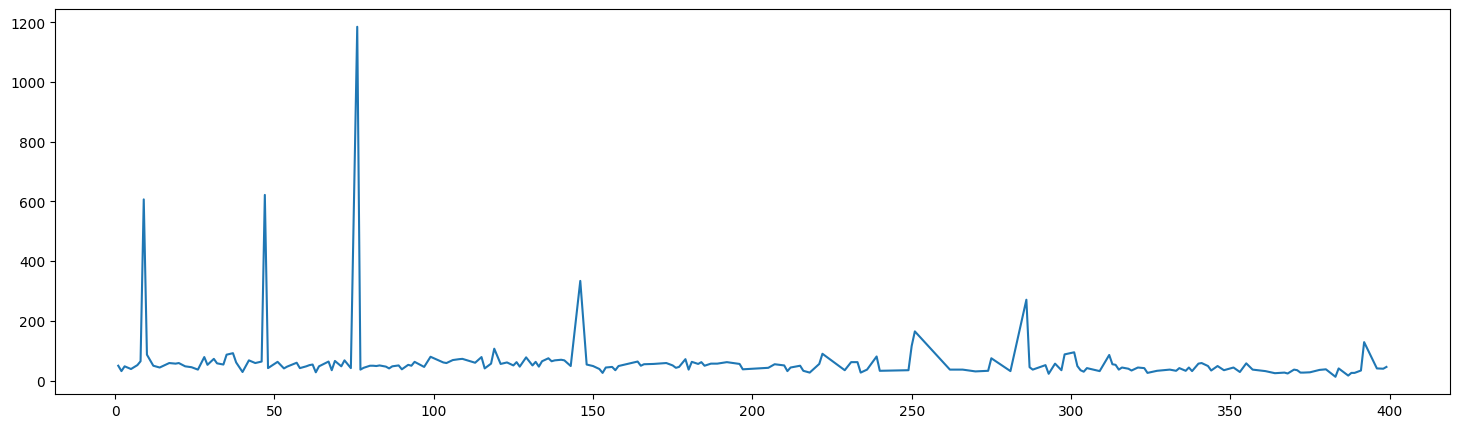

In [185]:
plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE)
plt.show()

In [186]:
# Check Outliers
print(data_modelling[data_modelling.MOVE == np.max(data_modelling.MOVE)])
print()
print(data_modelling.iloc[44:48])

    WEEK  PRICE  MOVE
46    76   0.79  1185

    WEEK  PRICE  MOVE
44    72   1.89    68
45    74   1.89    42
46    76   0.79  1185
47    77   1.89    37


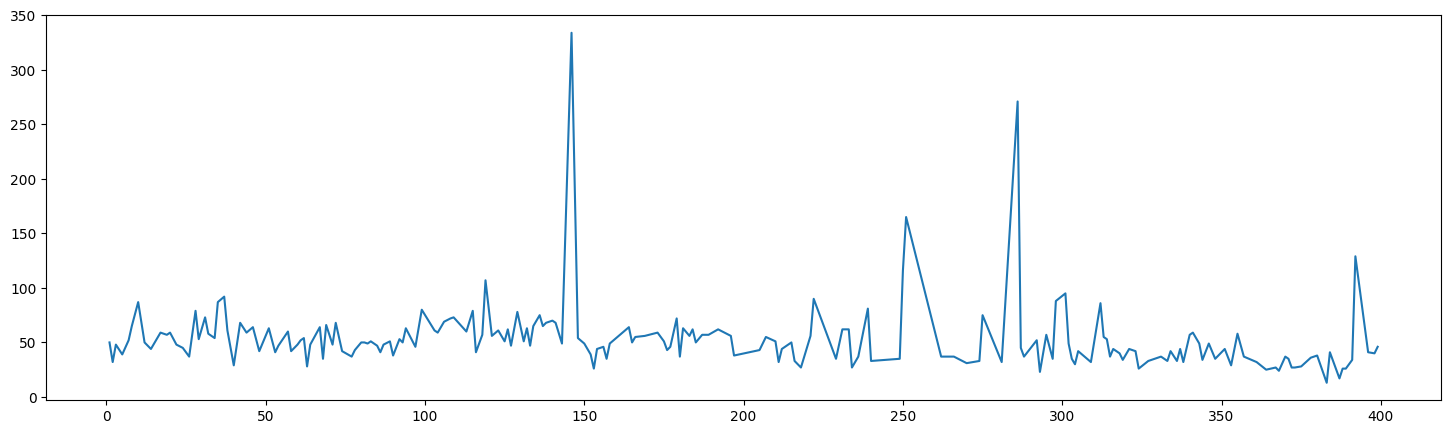

In [187]:
data_modelling = data_modelling.drop(index = data_modelling.nlargest(3, 'MOVE').index, axis = 0)

plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE)
plt.show()

## 1. Mooving Average

In [188]:
def mooving_average(series, window_size):
    forecast = []
    for i in range(window_size, len(series)):                        #  2 -> 201       
        forecast.append(series[i - window_size : i].mean())           # data_modelling.MOVE[0: 2].mean() -> week 3
    forecast = np.array(forecast)
    return forecast

WINDOW_SIZE = 8
mooving_avg = mooving_average(series = data_modelling['MOVE'], window_size = WINDOW_SIZE)

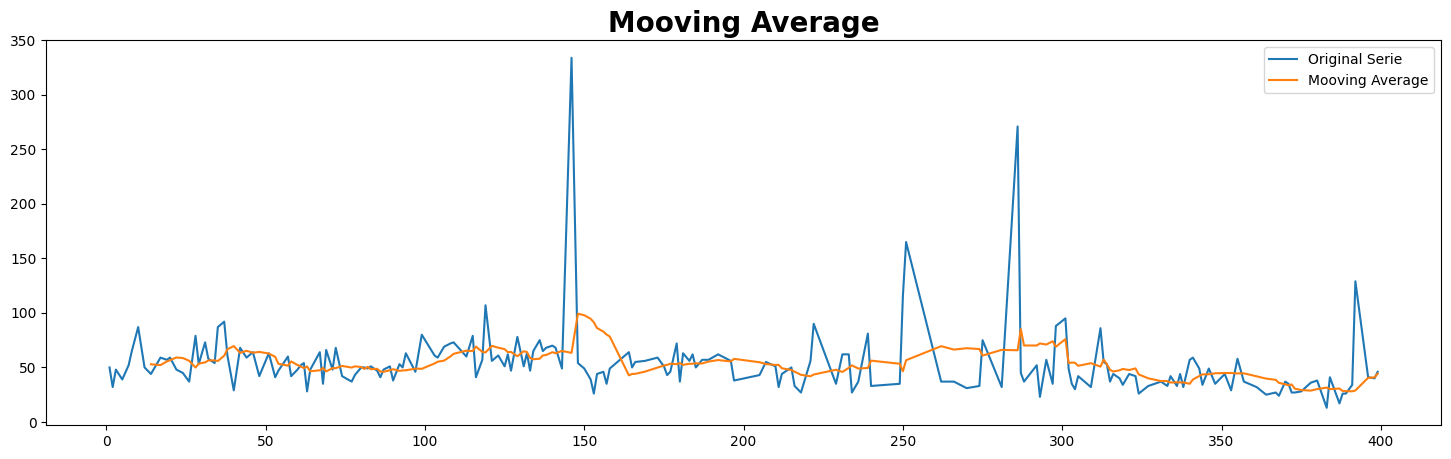

In [189]:
plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE, label = 'Original Serie')
plt.plot(data_modelling.WEEK[WINDOW_SIZE:], mooving_avg, label = 'Mooving Average')
plt.title('Mooving Average', fontsize = 20, fontweight = 'bold')
plt.legend()
plt.show()

In [190]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_true = data_modelling.MOVE[WINDOW_SIZE:], y_pred = mooving_avg)
print(MAE)

16.915592783505154


In [191]:
# Predict Week 400
prediction = data_modelling.tail(WINDOW_SIZE).MOVE.sum() / WINDOW_SIZE

# Confidence Intervale 
lower = prediction - MAE
upper = prediction + MAE

print(f'The prediction of sales for week 400 is: {prediction:.2f}.\nTypical Error Range: [{lower:.2f}, {upper:.2f}]')

The prediction of sales for week 400 is: 44.88.
Typical Error Range: [27.96, 61.79]


### Différenciation

Notre courbe oscille naturellement autour d'une ligne horizontale fixe, la différenciation n'est donc pas obligatoire, mais nous allons le tester tout de même pour vérifier si nous obtenons une meilleur métrique MAE. 

**Important:** Il est peu-être encore plus risquer de faire la différenciation dans notre série car nous avons observé la présence de Pics: Si la série est plate mais avec des sauts brusques et brefs -> différencier transformerait un pic en double choc inutile.

In [192]:
## Differenciation   
# Move_t - Move_(t-1)
diff_data = data_modelling[['MOVE']]
diff_data['prev'] = diff_data['MOVE'].shift(1)
diff_data['diff_MOVE'] = diff_data['MOVE'] - diff_data['prev']

diff_data = pd.concat((data_modelling.drop('MOVE', axis = 1), diff_data), axis = 1).dropna()
diff_data.head()

,WEEK,PRICE,MOVE,prev,diff_MOVE
1,2,1.79,32,50.0,-18.0
2,3,1.79,48,32.0,16.0
3,5,1.79,39,48.0,-9.0
4,7,1.79,52,39.0,13.0
5,8,1.79,65,52.0,13.0


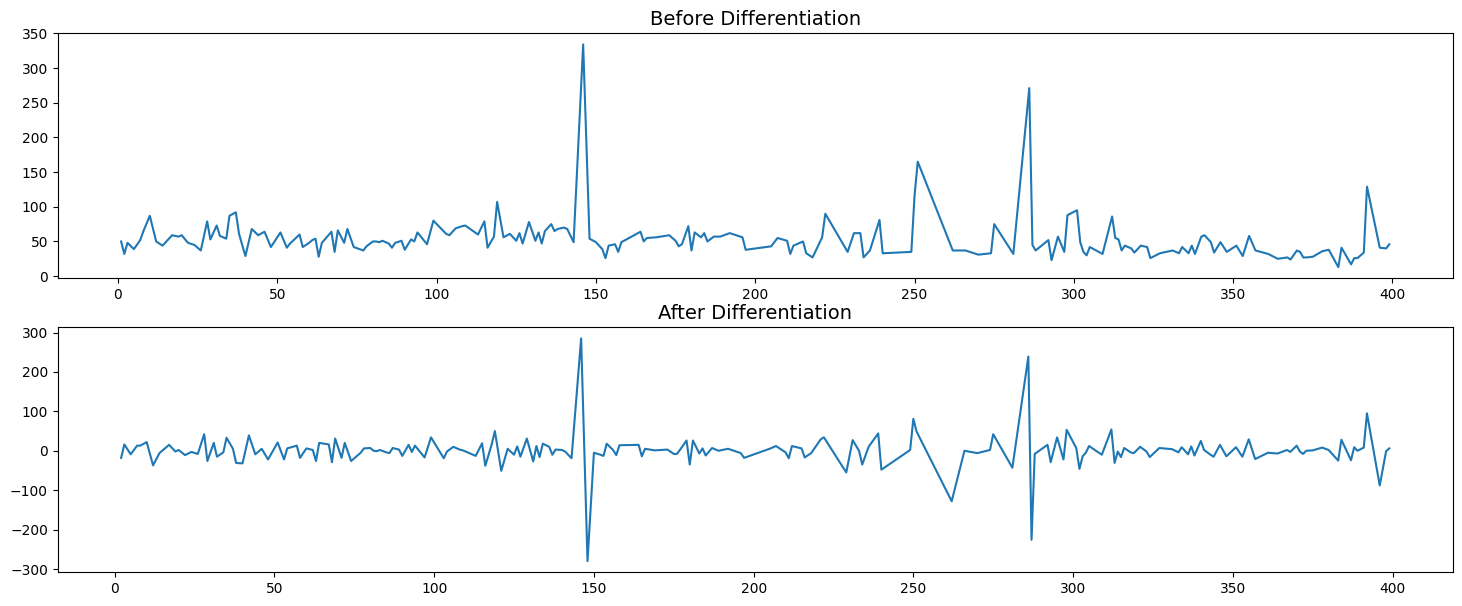

In [193]:
fig, (ax1, ax2) = plt.subplots(ncols = 1, nrows = 2, figsize = (18, 7))
ax1.plot(data_modelling.WEEK, data_modelling.MOVE)
ax1.set_title('Before Differentiation', fontsize = 14)

ax2.plot(diff_data.WEEK, diff_data.diff_MOVE)
ax2.set_title('After Differentiation', fontsize = 14)
plt.show()

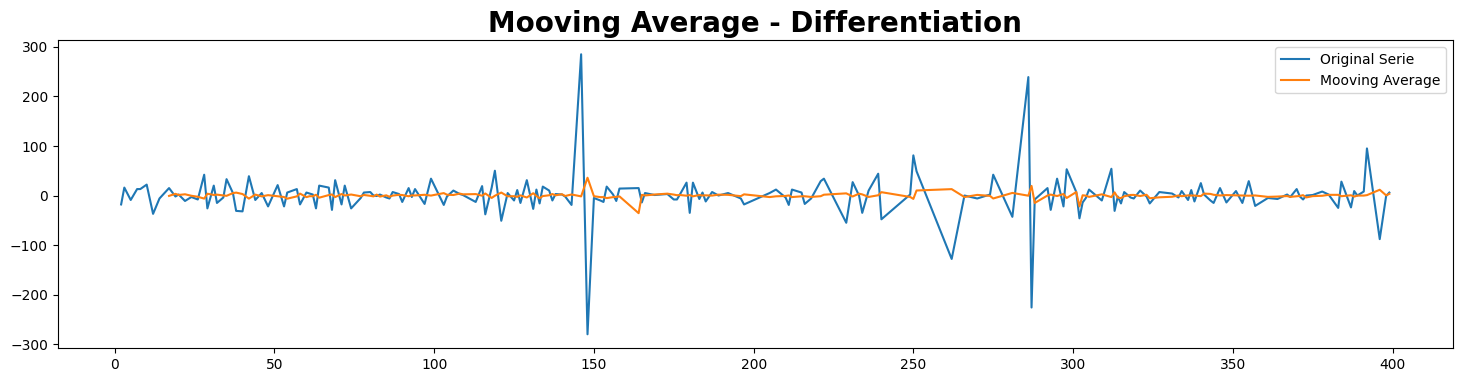

In [194]:
mooving_avg_diff = mooving_average(series = diff_data.diff_MOVE, window_size = WINDOW_SIZE)

plt.figure(figsize = (18, 4))
plt.plot(diff_data.WEEK, diff_data.diff_MOVE, label = 'Original Serie')
plt.plot(diff_data.WEEK[WINDOW_SIZE:], mooving_avg_diff, label = 'Mooving Average')
plt.title('Mooving Average - Differentiation', fontsize = 20, fontweight = 'bold')
plt.legend()
plt.show()

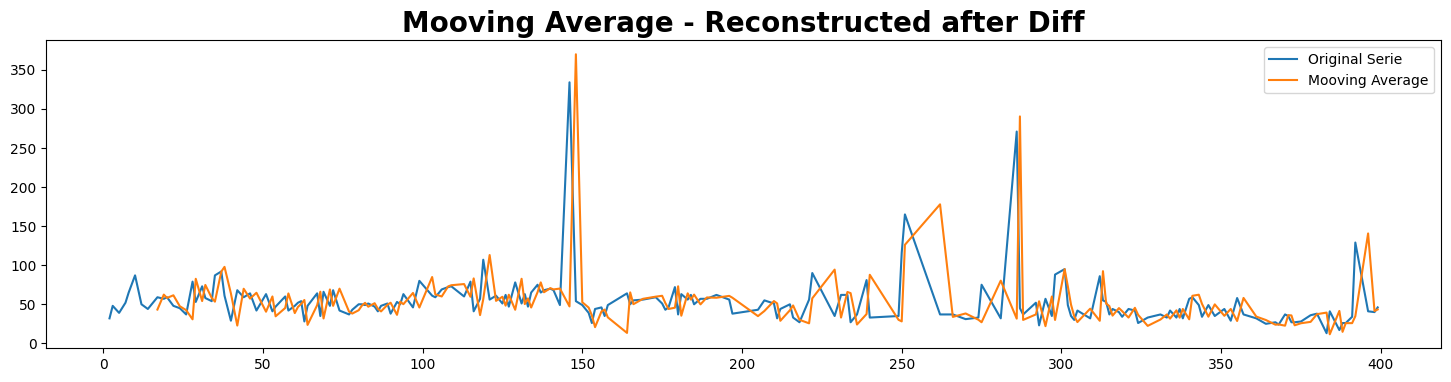

In [195]:
# real_value_t = real_value_(t -1) + pred_diff_t
reconstructed_pred = diff_data['prev'][WINDOW_SIZE:] + mooving_avg_diff

plt.figure(figsize = (18, 4))
plt.plot(diff_data.WEEK, diff_data.MOVE, label = 'Original Serie')
plt.plot(diff_data.WEEK[WINDOW_SIZE:], reconstructed_pred, label = 'Mooving Average')
plt.title('Mooving Average - Reconstructed after Diff', fontsize = 20, fontweight = 'bold')
plt.legend()
plt.show()

In [196]:
# worst MAE with diff
MAE_diff = mean_absolute_error(y_true = diff_data.MOVE[WINDOW_SIZE:], y_pred = reconstructed_pred)
print(MAE_diff)

22.76619170984456


## 2. Linear Regression Model

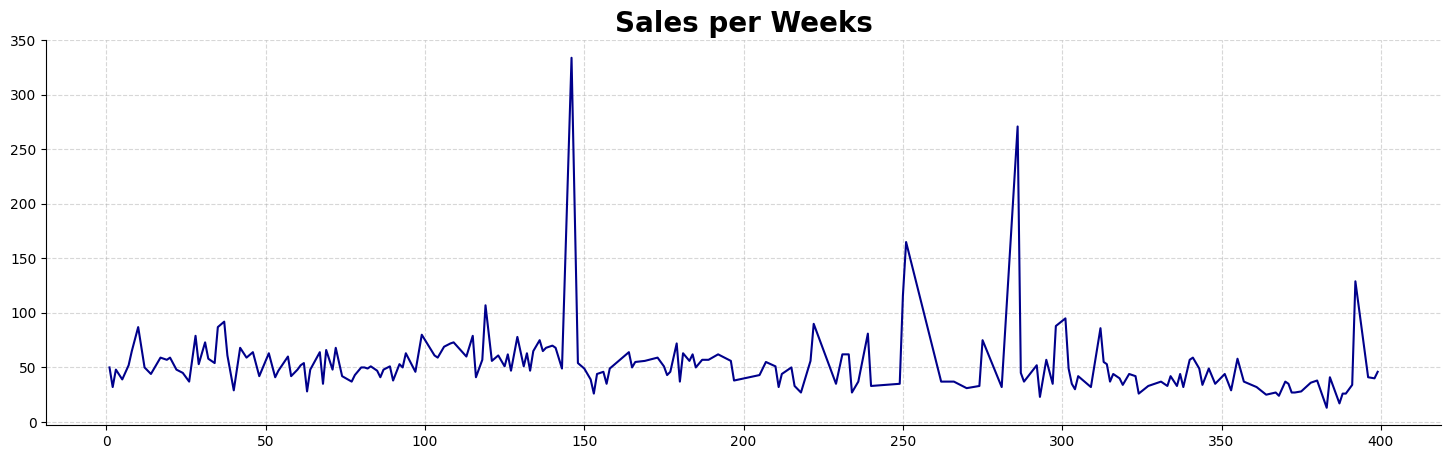

In [197]:
def plot(data_y, data_x, title:str = None):
    plt.figure(figsize = (18, 5))
    if title is not None:
        plt.title(title, fontsize = 20, fontweight = 'bold')
    plt.plot(data_x, data_y, color = 'darkblue')
    plt.grid(True, ls = '--', alpha = 0.5)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()

plot(data_x = data_modelling.WEEK, data_y = data_modelling.MOVE, title = 'Sales per Weeks')

In [198]:
# outliers
Q1 = data_modelling.MOVE.quantile(0.25)
Q3 = data_modelling.MOVE.quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

print(f'Upper: {upper}')
print(f'Lower: {lower}')

Upper: 93.875
Lower: 2.875


In [199]:
index_drop = data_modelling[data_modelling.MOVE > upper].index
#data_modelling['MOVE'] = data_modelling['MOVE'].drop(index = index_drop, axis = 0)

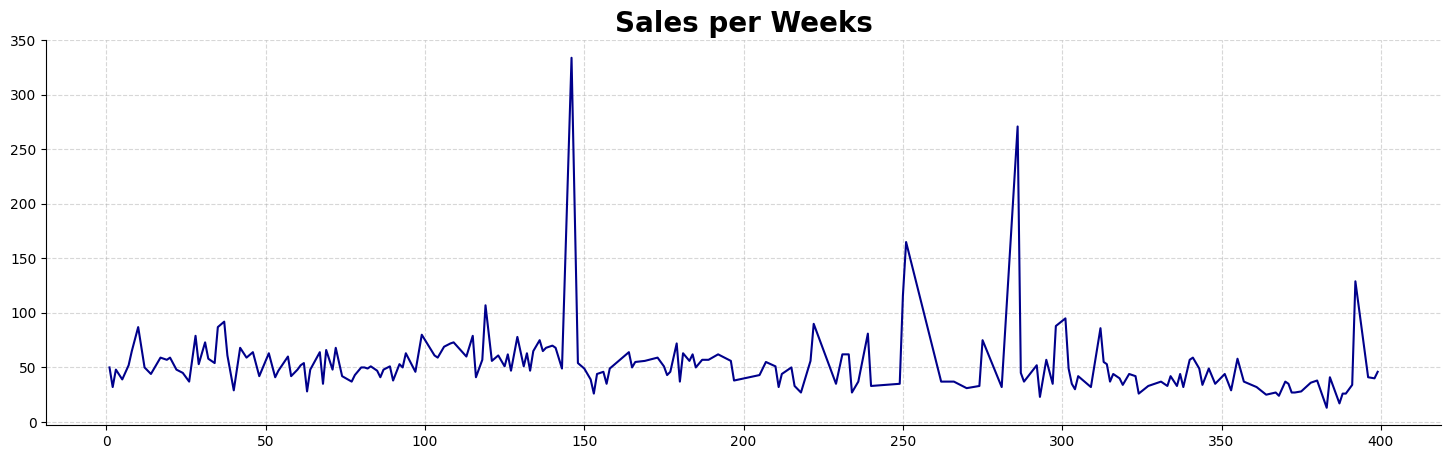

In [200]:
plot(data_x = data_modelling.WEEK, data_y = data_modelling.MOVE, title = 'Sales per Weeks')

In [201]:
from sklearn.linear_model import LinearRegression

data_modelling = data_modelling.dropna().reset_index(drop = True)

SPLITTER:int = int(data_modelling.shape[0] * 0.7)
x_train = data_modelling[['WEEK']][:SPLITTER]
x_test = data_modelling[['WEEK']][SPLITTER:]

y_train = data_modelling.MOVE[:SPLITTER]
y_test = data_modelling.MOVE[SPLITTER:]

lr = LinearRegression()
lr.fit(X = x_train, y = y_train)

LinearRegression()

In [202]:
pred = lr.predict(x_test)
print('MAE:', mean_absolute_error(y_true = y_test, y_pred = pred))
print('MSE:', mean_squared_error(y_true = y_test, y_pred = pred))

MAE: 30.81800112182879
MSE: 1074.6419381729604


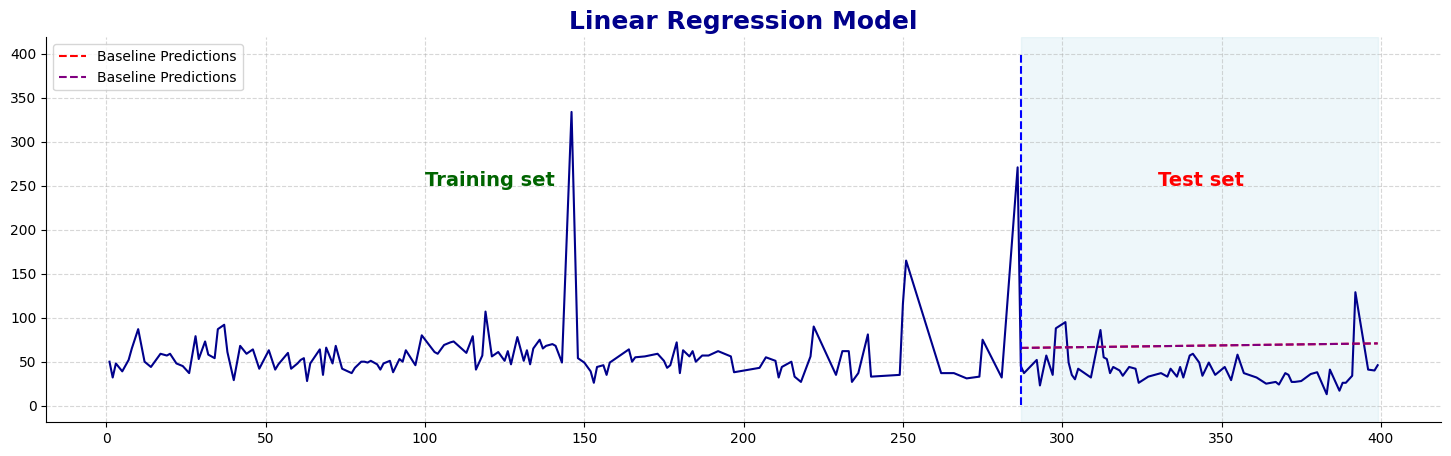

In [ ]:
plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE, color = 'darkblue')
plt.plot(x_test, pred, color = 'red', ls = '--', label = 'Baseline Predictions')
plt.grid(True, ls = '--', alpha = 0.5)
plt.title('Linear Regression Model', fontsize = 18, fontweight = 'bold', color = 'darkblue')
plt.annotate(text = 'Training set', xy = (100, 250), fontsize = 14, color = 'darkgreen', fontweight = 'bold')
plt.annotate(text = 'Test set', xy = (330, 250), fontsize = 14, color = 'red', fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvspan(xmin = data_modelling[data_modelling.index == SPLITTER].WEEK.values[0], xmax = data_modelling.WEEK.max(), color = 'lightblue', alpha = 0.2)
plt.vlines(x = data_modelling[data_modelling.index == SPLITTER].WEEK.values, ymin = np.min(data_modelling.WEEK), ymax = np.max(data_modelling.WEEK),
            linestyles = '--', color = 'blue')
plt.legend()
plt.show()

In [233]:
def lr_predict(X):
    return lr.coef_[0] * X + lr.intercept_

lr_predict(X = 407)

np.float64(71.15663020477686)

## Arima Model

In [255]:
from statsmodels.tsa.seasonal import seasonal_decompose

arima_model = data_modelling.copy()
arima_model = arima_model.drop('PRICE', axis = 1)
arima_model.set_index('WEEK', inplace = True)

In [ ]:
all_week = range(arima_model.index.min(), arima_model.index.max() + 1)

# Reindex data
arima_model = arima_model.reindex(all_week)

# Interpolate
arima_model.MOVE = arima_model.MOVE.interpolate()
arima_model.head()

,MOVE
WEEK,
1,50.0
2,32.0
3,48.0
4,43.5
5,39.0
...,...
395,63.0
396,41.0
397,40.5


In [261]:
decomposition = seasonal_decompose(arima_model['MOVE'], model = 'additive', period = 52)

trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

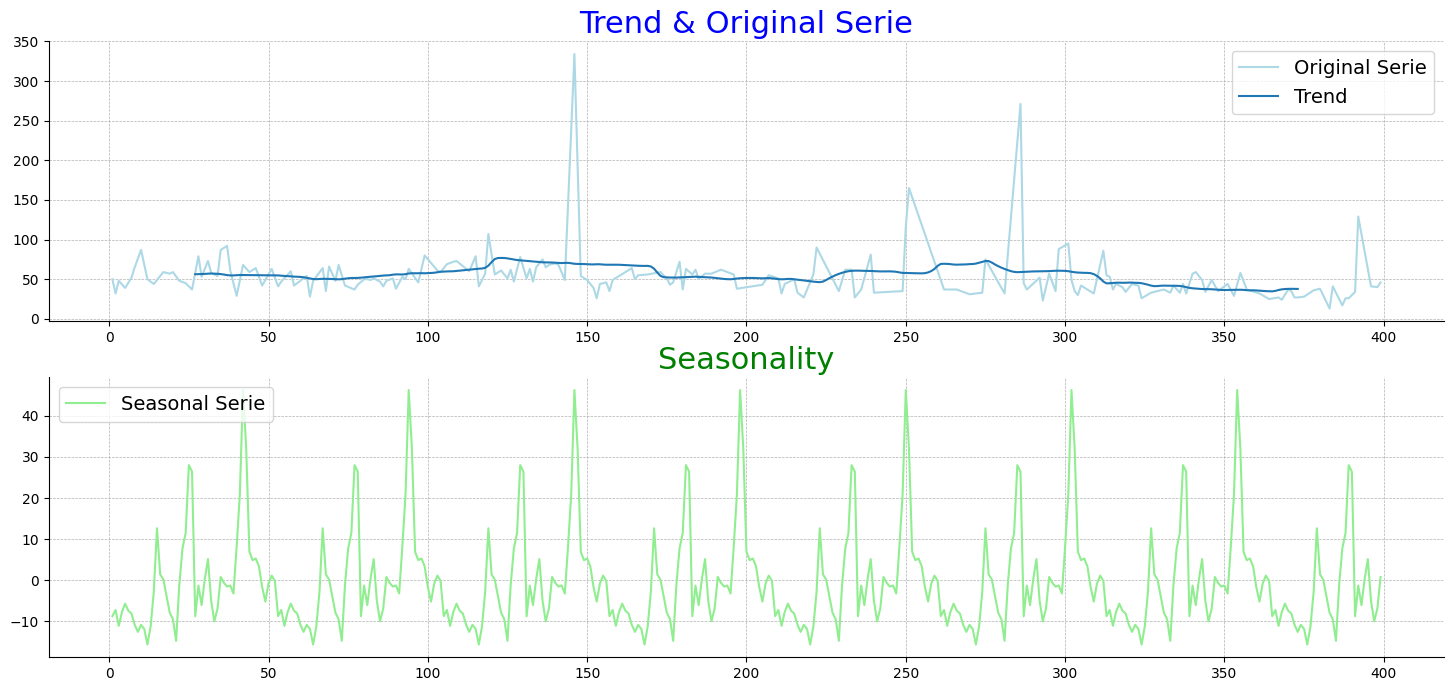

In [264]:
fig, (ax1, ax2) = plt.subplots(ncols=1, nrows=2, figsize = (18,8))

ax1.plot(arima_model, label = 'Original Serie', color = 'lightblue')
ax1.plot(trend, label = 'Trend')
ax1.grid(True, ls = '--', lw = 0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Trend & Original Serie', size = 22, color = 'blue')
ax1.legend(fontsize = 14)

ax2.plot(seasonality, label = 'Seasonal Serie', c = 'lightgreen')
ax2.grid(True, ls = '--', lw = 0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Seasonality', size = 22, color = 'green')
ax2.legend(loc = 'upper left', fontsize = 14)
plt.show()

1. La série n'est pas "explosive" (pas de croissance exponentielle). C'est bon signe pour la modélisation, car elle sera plus facile à rendre stationnaire (une condition clé pour ARIMA). Une simple différenciation (d=1) suffira probablement.
2. **Important**: La tendance semble ignorer les pics massifs. Cela signifie que la méthode de décomposition (moyenne mobile) considère ces pics comme du "bruit" et non comme un changement structurel du marché.